In [1]:
import json
import os

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import numpy as np

In [2]:
def load_json(path):
    with open(path) as fhand:
        return json.load(fhand)

In [3]:
datasets = [
    'hmof', 'hmofheat', 'cof', 'ppn',
    'zeolite', 'c3h6c3h8coremof', 'ch4n2'
]

In [4]:
metric = 'test_MeanAbsoluteError'

ckpt_paths = [
    'from_scratch-to_',
    'from_experiments_pretrain_early_pretrain_lightning_logs_version_0_checkpoints_best.ckpt-to_',
]

train_sizes = [50, 100, 300, 500, 1000]
sizes_runs = {'50': '10', '100': '10', '300': '5', '500': '5', '1000': '3'}

results_dict = {mode: {s: dict(mean=[]) for s in sizes_runs.keys()} for mode in ['scratch', 'finetune']}

for ds in datasets:
    for task in set([i.split('-to_')[-1] for i in os.listdir(f'../experiments/evaluate/few_shot/{ds}/')]):
        print(task)
        for ckpt, mode in zip(ckpt_paths, ['scratch', 'finetune']):
            # Load results for each dataset, dataset and mode
            json_path = f'../experiments/evaluate/few_shot/{ds}/{ckpt}{task}/results.json'
            results = load_json(json_path)
        
            # Add the mean across runs
            for size, n_runs in sizes_runs.items():
                mean = np.mean([
                    np.array([results[size][str(run)][metric] for run in range(int(n_runs))])
                ])
                #std = np.std([
                #    np.array([results[size][str(run)][metric] for run in range(int(n_runs))])
                #])
                results_dict[mode][size]['mean'].append(mean.item())
                #results_dict[mode][size]['std'].append(std.item())

H2-77-2
CO2-298-2.5
Xe-273-10
Kr-273-10
N2-298-0.9
CH4-298-2.5
CO2-298K-2.5bar
H2-77K-2bar
highbar
lowbar
65bar
1bar
heat_of_adsorption
unitless_KH
C3H6_loadings
C3H8_loadings
C3H8_C3H6_Selectivity_infinite
C3H8_Henry_298K
C3H6_Henry_298K
TSN_S_1Bar
C3H8_C3H6_Selectivity_1bar
n2uptake-1bar
ch4uptake-1bar
n2uptake-10bar
n2uptake-0.1bar
ch4n2ratio-0.1bar
ch4n2ratio-1bar
ch4uptake-0.1bar
ch4uptake-10bar
ch4n2ratio-10bar


In [5]:
palette = sns.color_palette()
sns.set_theme()
#sns.set_palette('muted')

## Relative improvement vs training size

In [6]:
relative_dict = {}
for size in sizes_runs.keys():
    sc = np.array(results_dict['scratch'][size]['mean'])
    ft = np.array(results_dict['finetune'][size]['mean'])
    rel = - 100 * (ft - sc) / sc
    relative_dict[size] = rel

In [7]:
relative_dict

{'50': array([28.90239036, 47.1765625 , 46.51094217, 34.87686513, 61.01346664,
        61.42830449, 25.24334286, 15.06647355, 33.41409751, 37.99093185,
        23.03377353, 33.49003593, 22.32480936, 20.00846575, 32.67651697,
        34.47349708,  8.97311604, 39.47082649, 55.80777249, 18.37122209,
         3.35779498, 50.24803637, 49.77163229, 33.90645045, 57.17896389,
        37.25409091, 42.21103873, 55.02607195, 46.46603207, 35.24900706]),
 '100': array([32.11554874, 48.81258934, 47.70893078, 42.55904531, 58.34335655,
        62.4187962 , 23.80185488, 15.38086391, 33.60742371, 34.27320007,
        29.98452581, 36.48845258, 11.86006506, 17.0584531 , 29.86216768,
        31.17725103,  1.84760912, 42.71431246, 57.39392251, 16.74105274,
         6.15060219, 37.9424435 , 43.19356669, 29.35043714, 54.20180339,
        28.79292607, 35.04363173, 51.12067509, 40.98066363, 32.66350468]),
 '300': array([24.31638036, 47.16007506, 42.91210442, 40.35747309, 53.99168145,
        57.99384215, 22.674

In [8]:
len(relative_dict['50'])

30

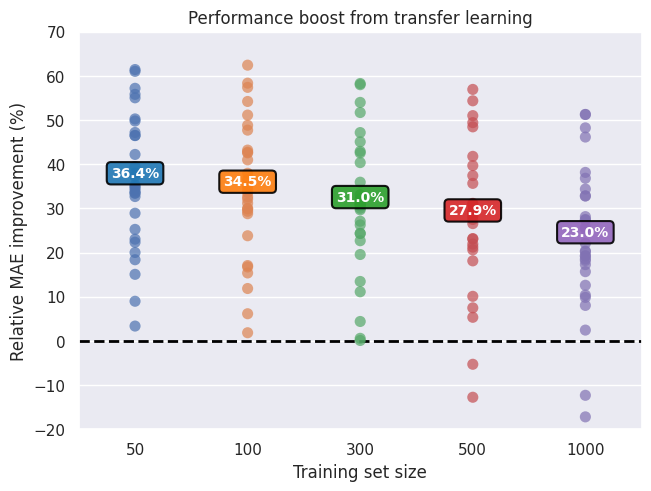

In [9]:
fig, ax = plt.subplots(layout='constrained')

colors = plt.cm.viridis(np.linspace(0, 1, 10))

sns.stripplot(relative_dict, ax=ax, s=8, alpha=0.7, jitter=0)
ax.axhline(0, c='black', ls='--', lw=2)

means = [np.mean(v) for v in relative_dict.values()]
for i, (size, mean_val) in enumerate(zip(relative_dict.keys(), means)):
    ax.text(
        i, mean_val,
        f'{mean_val:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='white',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor=palette[i],
            edgecolor='black',
            linewidth=1.5,
            alpha=0.9
        )
    )

ax.set_ylim(-20, 70)
ax.set_xlabel('Training set size')

ax.set_ylabel('Relative ΜΑΕ improvement (%)')
ax.set_title('Performance boost from transfer learning')

plt.savefig('figures/tl_analysis.pdf')